## 1. Data Ingestion

The traffic count dataset is split across four quarterly tables in the Databricks metastore, covering Q1 through Q4. Each table shares the same schema. We load all four into Spark DataFrames and union them into a single unified DataFrame for downstream processing.

In [0]:
# Read all four quarterly tables
df_q1 = spark.table("traffic_count_data_2019_q1")
df_q2 = spark.table("traffic_count_data_2019_q2")
df_q3 = spark.table("traffic_count_data_2019_q3")
df_q4 = spark.table("traffic_count_data_2019_q4")

# Union all quarters into a single DataFrame
df = df_q1.union(df_q2).union(df_q3).union(df_q4)

print(f"Q1 records     : {df_q1.count():,}")
print(f"Q2 records     : {df_q2.count():,}")
print(f"Q3 records     : {df_q3.count():,}")
print(f"Q4 records     : {df_q4.count():,}")
print(f"Total records  : {df.count():,}")

Q1 records     : 2,065,423
Q2 records     : 2,126,017
Q3 records     : 1,824,756
Q4 records     : 1,563,515
Total records  : 7,579,711


## 2. Initial Data Exploration
A quick peek at the data before any cleaning — view sample rows, shape, and basic info.

In [0]:
# Print full schema
print("=== DataFrame Schema ===")
df.printSchema()

=== DataFrame Schema ===
root
 |-- cosit: long (nullable = true)
 |-- lane: long (nullable = true)
 |-- year: long (nullable = true)
 |-- month: long (nullable = true)
 |-- day: long (nullable = true)
 |-- hour: long (nullable = true)
 |-- vehicle_count: long (nullable = true)
 |-- avg_speed: double (nullable = true)
 |-- max_speed: double (nullable = true)
 |-- min_speed: double (nullable = true)
 |-- speed_std: double (nullable = true)
 |-- avg_length: double (nullable = true)
 |-- max_length: double (nullable = true)
 |-- length_std: double (nullable = true)
 |-- avg_headway: double (nullable = true)
 |-- max_headway: double (nullable = true)
 |-- min_headway: double (nullable = true)
 |-- headway_std: double (nullable = true)
 |-- avg_gap: double (nullable = true)
 |-- max_gap: double (nullable = true)
 |-- min_gap: double (nullable = true)
 |-- gap_std: double (nullable = true)
 |-- CAR_count: long (nullable = true)
 |-- HGV_ART_count: long (nullable = true)
 |-- BUS_count: long (

In [0]:
# Show first few rows
display(df)

# Shape
print(f"Rows    : {df.count():,}")
print(f"Columns : {len(df.columns)}")

cosit,lane,year,month,day,hour,vehicle_count,avg_speed,max_speed,min_speed,speed_std,avg_length,max_length,length_std,avg_headway,max_headway,min_headway,headway_std,avg_gap,max_gap,min_gap,gap_std,CAR_count,HGV_ART_count,BUS_count,HGV_RIG_count,CARAVAN_count,LGV_count,MBIKE_count
20092,3,2019,2,24,17,215,119.78139534883721,142.0,83.0,9.722967697552109,4.444186046511628,17.3,0.9284954983512822,15.049953488372093,154.8,0.0,20.48705810988553,15.065023255813951,154.65,0.0,20.500194457122358,202,1,0,0,0,12,0
20093,3,2019,2,24,12,66,114.77272727272727,142.0,16.0,15.678300000608832,4.357575757575757,5.9,0.7010016144084573,45.16227272727273,396.8,0.0,64.09325839492264,44.887727272727275,396.61,0.0,64.17296899894735,63,0,0,0,0,3,0
20701,2,2019,2,24,19,64,82.375,101.0,60.0,8.961115293398874,4.59375,13.0,1.215491931244562,46.0340625,244.2,0.0,59.3032447443003,45.78656250000001,243.99,0.0,59.34933535469163,58,0,1,0,0,5,0
20153,1,2019,2,24,15,315,96.21269841269842,124.0,69.0,8.916589635104748,4.541904761904764,17.4,1.054995482742853,10.663777777777781,101.2,0.0,14.567257238534808,10.410444444444442,101.04,0.0,14.615738935907563,294,0,2,2,1,16,0
20172,1,2019,2,24,15,6,54.5,87.0,14.0,24.647515087732476,3.6666666666666665,4.4,1.2176480060619599,10.933333333333332,35.2,0.0,17.005724526366603,10.854999999999999,34.9,0.0,16.881212930355446,5,0,0,0,0,0,1
20212,1,2019,2,24,15,669,98.41106128550075,128.0,68.0,8.599362717169692,4.554260089686098,14.0,0.8266521822723757,5.350866965620327,39.3,0.0,5.510292152556601,5.095994020926758,39.15,0.0,5.574050584281764,603,1,2,3,2,58,0
20184,4,2019,2,24,11,869,91.50402761795166,139.0,16.0,9.028451948650899,4.539930955120829,17.1,1.0411379341817728,4.185684695051785,27.6,0.0,3.429274640423894,3.9087571921749142,27.43,0.0,3.498617346673094,815,2,5,1,4,42,0
20202,2,2019,2,24,12,458,96.83624454148472,162.0,31.0,9.787537105083926,4.610698689956333,15.2,1.1235665084666557,7.690742358078605,56.1,0.0,8.318211170946556,7.42864628820961,55.92,0.0,8.37609604973293,392,1,3,1,3,54,4
20801,1,2019,2,24,12,419,63.856801909307876,97.0,37.0,9.788603875134722,4.414081145584727,13.2,0.9377093657651399,8.489713603818615,102.1,0.0,13.085724897384543,8.006968973747016,101.89,0.0,13.203745739616895,395,1,2,2,1,11,6
20908,3,2019,2,24,12,60,118.38333333333334,152.0,91.0,14.015840513887653,4.163333333333334,4.9,0.5148528394868613,42.423166666666674,277.9,0.0,56.74331969915248,45.41483333333333,277.8,0.0,57.60085390997422,59,0,0,0,0,0,1


Rows    : 7,579,711
Columns : 29


## 3. Data Cleaning

Data cleaning is a critical step to ensure the quality and reliability of our dataset before analysis and model training. We address the following issues in order

### 3.1 Removing Duplicate Rows
Duplicate records can skew analysis and model training. We first check how many duplicate rows exist in the unified DataFrame, then remove them and confirm the result.

In [0]:
# Count before
total_before = df.count()
# Count duplicates
duplicate_count = df.count() - df.dropDuplicates().count()
print(f"Total rows before deduplication : {total_before:,}")
print(f"Duplicate rows found            : {duplicate_count:,}")
# Remove duplicates
df = df.dropDuplicates()
# Confirm
total_after = df.count()
print(f"Total rows after deduplication  : {total_after:,}")
print(f"Rows removed                    : {total_before - total_after:,}")

Total rows before deduplication : 7,579,711
Duplicate rows found            : 0
Total rows after deduplication  : 7,579,711
Rows removed                    : 0


### 3.2 Handling Missing / Null Values
Missing values can negatively impact model performance and introduce bias into our analysis. We begin by inspecting the null value count across all columns to understand the extent of missingness before deciding on an appropriate handling strategy.

In [0]:
from pyspark.sql.functions import col, sum as spark_sum

# Count nulls per column
total_rows = df.count()

print(f"{'#':<5} {'Column':<30} {'Null Count':>12} {'Null %':>10} {'Status':>8}")
print("-" * 70)

for i, col_name in enumerate(df.columns):
    null_val = df.filter(col(col_name).isNull()).count()
    pct = (null_val / total_rows) * 100
    flag = "NULLS" if null_val > 0 else "CLEAN"
    print(f"{i+1:<5} {col_name:<30} {null_val:>12,} {pct:>9.2f}%   {flag}")

print("-" * 70)
print(f"\nTotal Rows : {total_rows:,}")
print(f"Total Cols : {len(df.columns)}")

#     Column                           Null Count     Null %   Status
----------------------------------------------------------------------
1     cosit                                     0      0.00%   CLEAN
2     lane                                      0      0.00%   CLEAN
3     year                                      0      0.00%   CLEAN
4     month                                     0      0.00%   CLEAN
5     day                                       0      0.00%   CLEAN
6     hour                                      0      0.00%   CLEAN
7     vehicle_count                             0      0.00%   CLEAN
8     avg_speed                                 0      0.00%   CLEAN
9     max_speed                                 0      0.00%   CLEAN
10    min_speed                                 0      0.00%   CLEAN
11    speed_std                           107,850      1.42%   NULLS
12    avg_length                                0      0.00%   CLEAN
13    max_length               

Four columns — `speed_std`, `length_std`, `headway_std`, and `gap_std` — each contain **107,850 null values (1.42%)**, all occurring on the same rows. These columns were derived during aggregation, and nulls arise when only a **single vehicle** was recorded in a time interval, making standard deviation mathematically undefined. Therefore, we impute these nulls with **0**, as a single observation has zero variability by definition.

In [0]:
# Impute std columns with 0 (single vehicle observation = zero variability)
std_cols = ["speed_std", "length_std", "headway_std", "gap_std"]

df = df.fillna(0, subset=std_cols)

# Verify no nulls remain
print(f"{'Column':<20} {'Remaining Nulls':>15}")
print("-" * 38)
for c in std_cols:
    remaining = df.filter(col(c).isNull()).count()
    print(f"{c:<20} {remaining:>15,}")

Column               Remaining Nulls
--------------------------------------
speed_std                          0
length_std                         0
headway_std                        0
gap_std                            0


### 3.3 Outlier Detection — SparkML K-Means Anomaly Scoring

We apply a score-based outlier detection approach using SparkML K-Means clustering. Each row is assigned to its nearest cluster centre, and the Euclidean distance to that centre serves as an anomaly score — rows that are far from any cluster centre are considered anomalous. This produces an interpretable continuous score, allowing us to identify a natural threshold from the score distribution rather than imposing an arbitrary percentage.

We use K=5 clusters, reflecting the natural traffic patterns present in hourly data such as night hours, off-peak, morning peak, afternoon peak, and evening periods. Outlier rows are first flagged and inspected before any removal decision is made.

In [0]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType
import numpy as np

numerical_cols = [
    "vehicle_count", "avg_speed", "max_speed", "min_speed", "speed_std",
    "avg_length", "max_length", "length_std",
    "avg_headway", "max_headway", "min_headway", "headway_std",
    "avg_gap", "max_gap", "min_gap", "gap_std",
    "CAR_count", "HGV_ART_count", "BUS_count", "HGV_RIG_count",
    "CARAVAN_count", "LGV_count", "MBIKE_count"
]

assembler = VectorAssembler(inputCols=numerical_cols, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
kmeans    = KMeans(featuresCol="features", predictionCol="cluster", k=5, seed=42)
pipeline  = Pipeline(stages=[assembler, scaler, kmeans])

print("Fitting K-Means pipeline...")
model        = pipeline.fit(df)
df_clustered = model.transform(df)
print("K-Means fitted successfully")

# Get cluster centres as plain numpy arrays
centres = model.stages[-1].clusterCenters()

def distance_to_centre(features, cluster_idx):
    centre = centres[cluster_idx]
    return float(np.sqrt(np.sum((np.array(features) - centre) ** 2)))

distance_udf = udf(distance_to_centre, DoubleType())

df_scored = df_clustered.withColumn(
    "anomaly_score",
    distance_udf(col("features"), col("cluster"))
)

print("Anomaly scores computed successfully")
print("Total rows scored :", f"{df_scored.count():,}")

Fitting K-Means pipeline...
K-Means fitted successfully
Anomaly scores computed successfully
Total rows scored : 7,579,711


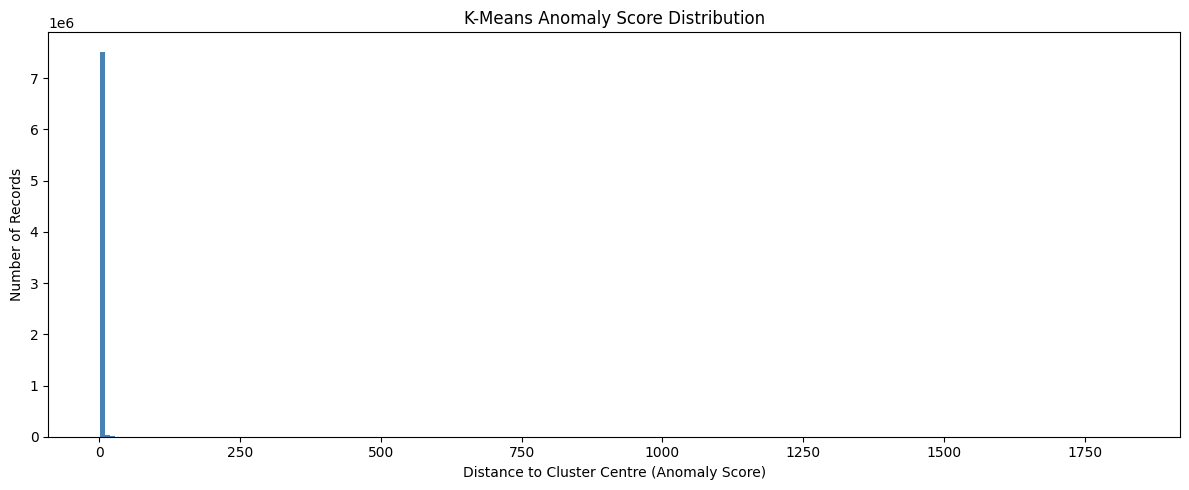

Anomaly score summary:
count    7.579711e+06
mean     2.913400e+00
std      2.292400e+00
min      2.738000e-01
25%      1.883400e+00
50%      2.482700e+00
75%      3.392300e+00
max      1.827736e+03
Name: anomaly_score, dtype: float64


In [0]:
import matplotlib.pyplot as plt

# Get full anomaly scores
full_score_pdf = df_scored.select("anomaly_score").toPandas()

plt.figure(figsize=(12, 5))
plt.hist(full_score_pdf["anomaly_score"], bins=200, color="steelblue", edgecolor="none")
plt.title("K-Means Anomaly Score Distribution")
plt.xlabel("Distance to Cluster Centre (Anomaly Score)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

print("Anomaly score summary:")
print(full_score_pdf["anomaly_score"].describe().round(4))

#### Threshold Selection

The anomaly score distribution is heavily right-skewed, with the majority of records scoring between 1.88 and 3.39, while the maximum reaches 172.17 — indicating a small number of extreme anomalies. we adopt the **99th percentile** as the threshold — a robust, data-driven cutoff that flags the top 1% most anomalous hours while preserving 99% of the dataset.

In [0]:
threshold = full_score_pdf["anomaly_score"].quantile(0.99)

print("Selected threshold (99th percentile):", round(threshold, 4))

Selected threshold (99th percentile): 8.9896


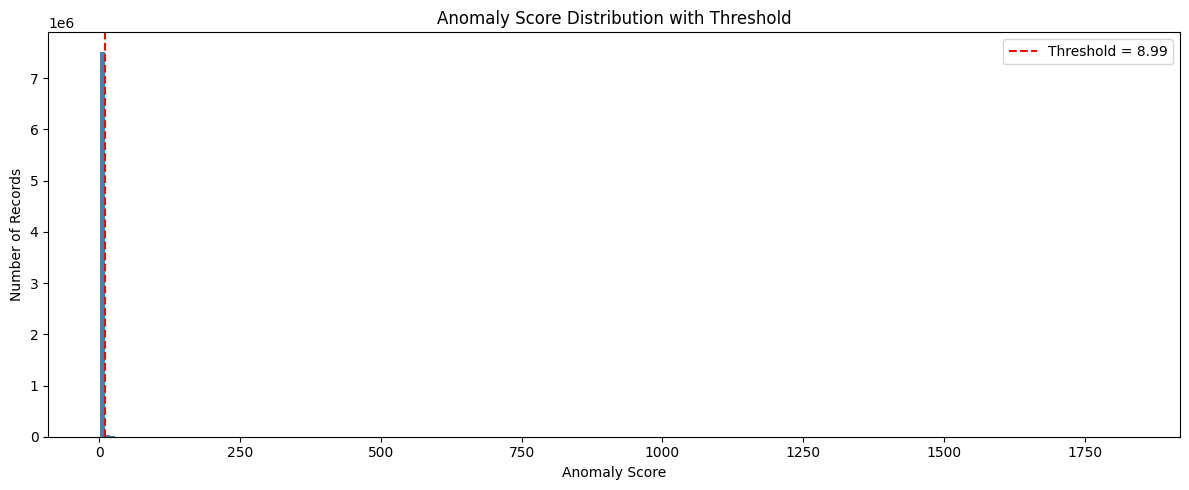

In [0]:
import matplotlib.pyplot as plt

normal_count  = len(full_score_pdf[full_score_pdf["anomaly_score"] <= threshold])
outlier_count = len(full_score_pdf[full_score_pdf["anomaly_score"] >  threshold])

plt.figure(figsize=(12, 5))
plt.hist(full_score_pdf["anomaly_score"], bins=200, color="steelblue", edgecolor="none")
plt.axvline(x=threshold, color="red", linestyle="--", linewidth=1.5, label=f"Threshold = {round(threshold, 2)}")
plt.title("Anomaly Score Distribution with Threshold")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Records")
plt.legend()
plt.tight_layout()
plt.show()

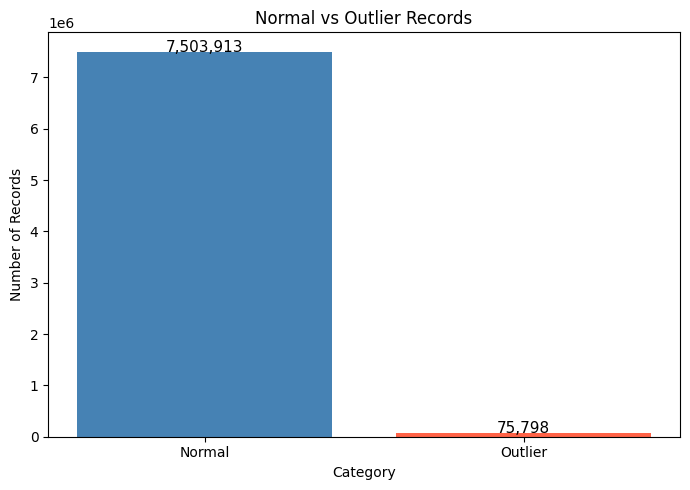

Normal rows  : 7,503,913 (99.00%)
Outlier rows : 75,798 (1.00%)


In [0]:
plt.figure(figsize=(7, 5))
plt.bar(["Normal", "Outlier"], [normal_count, outlier_count], color=["steelblue", "tomato"])
plt.title("Normal vs Outlier Records")
plt.xlabel("Category")
plt.ylabel("Number of Records")
for i, v in enumerate([normal_count, outlier_count]):
    plt.text(i, v + 500, f"{v:,}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

print("Normal rows  :", f"{normal_count:,}", f"({normal_count/len(full_score_pdf)*100:.2f}%)")
print("Outlier rows :", f"{outlier_count:,}", f"({outlier_count/len(full_score_pdf)*100:.2f}%)")

In [0]:
# Remove outlier rows and drop intermediate columns
df_clean = df_scored.filter(col("anomaly_score") <= threshold).drop("features_raw", "features", "cluster", "anomaly_score")

print("Rows before outlier removal :", f"{df_scored.count():,}")
print("Rows after outlier removal  :", f"{df_clean.count():,}")
print("Outlier rows removed        :", f"{df_scored.count() - df_clean.count():,}")

# Overwrite df with clean version
df = df_clean

Rows before outlier removal : 7,579,711
Rows after outlier removal  : 7,503,913
Outlier rows removed        : 75,798


### 3.4 Data Cleaning Summary

The following cleaning steps were applied to the unified dataset:

| Step | Finding | Action | Rows Affected |
|---|---|---|---|
| Duplicate Removal | 0 duplicates found | None required | 0 |
| Null Value Imputation | 107,850 nulls in 4 std columns | Imputed with 0 | 107,850 values |
| Outlier Removal | 75,383 anomalous rows detected via K-Means | Removed | 75,383 rows |

The dataset reduced from **7,579,711** to **7,504,328** rows after cleaning, retaining **99.01%** of the original data. The cleaned DataFrame is now ready for feature engineering.

## 4. Feature Engineering

Although the dataset is entirely numerical, introducing categorical features derived from existing columns adds interpretability and enables richer analysis. These features capture domain-specific patterns in traffic behaviour that raw numerical values alone do not express clearly.

### 4.1 Time of Day
A categorical feature `time_of_day` is derived from the `hour` column, grouping the 24 hours of the day into four meaningful periods — Night, Morning, Afternoon, and Evening. This feature captures the temporal pattern of traffic behaviour throughout the day.

In [0]:
from pyspark.sql.functions import when

df = df.withColumn("time_of_day",
    when((col("hour") >= 0)  & (col("hour") <= 5),  "Night")
    .when((col("hour") >= 6)  & (col("hour") <= 11), "Morning")
    .when((col("hour") >= 12) & (col("hour") <= 17), "Afternoon")
    .when((col("hour") >= 18) & (col("hour") <= 23), "Evening")
)

# Verify distribution
display(df.groupBy("time_of_day").count().orderBy("time_of_day"))

time_of_day,count
Afternoon,1900756
Evening,1903593
Morning,1895483
Night,1804081


### 4.2 Day Type
A categorical feature `day_type` is derived from the `day` column, classifying each record as either a Weekday or Weekend. This feature is particularly relevant for traffic analysis as traffic volumes and patterns differ significantly between working days and weekends.

In [0]:
from pyspark.sql.functions import dayofweek, to_date, concat_ws, lpad

df = df.withColumn("date_col", 
        to_date(concat_ws("-", col("year"), lpad(col("month"), 2, "0"), lpad(col("day"), 2, "0")), "yyyy-MM-dd")
    ).withColumn("day_type",
        when(dayofweek(col("date_col")).isin([1, 7]), "Weekend")
        .otherwise("Weekday")
    ).drop("date_col")

# Verify distribution
display(df.groupBy("day_type").count().orderBy("day_type"))

day_type,count
Weekday,5335991
Weekend,2167922


### 4.3 Traffic Level
A categorical feature `traffic_level` is derived from the `vehicle_count` column, classifying each hour into four traffic intensity bands. This feature provides an intuitive representation of traffic volume that is more interpretable than raw counts.

In [0]:
# Check vehicle_count distribution first
display(df.select("vehicle_count").summary("min", "25%", "50%", "75%", "max"))

summary,vehicle_count
min,1
25%,43
50%,161
75%,418
max,2594


In [0]:
df = df.withColumn("traffic_level",
    when(col("vehicle_count") <= 43,  "Low")
    .when(col("vehicle_count") <= 161, "Medium")
    .when(col("vehicle_count") <= 418, "High")
    .otherwise("Very High")
)

# Verify distribution
display(df.groupBy("traffic_level").count().orderBy("traffic_level"))

traffic_level,count
High,1872977
Low,1879647
Medium,1880189
Very High,1871100


### 4.4 Speed Category
A categorical feature `speed_category` is derived from the `avg_speed` column, classifying each hourly record into speed bands. As with traffic level, bin boundaries are determined from the quartile distribution of average speed values.

In [0]:
# Check avg_speed distribution first
display(df.select("avg_speed").summary("min", "25%", "50%", "75%", "max"))

summary,avg_speed
min,0.0
25%,83.69444444444444
50%,94.42693409742121
75%,108.22556390977444
max,224.5


In [0]:
df = df.withColumn("speed_category",
    when(col("avg_speed") <= 83.69,  "Slow")
    .when(col("avg_speed") <= 94.43, "Moderate")
    .when(col("avg_speed") <= 108.23, "Fast")
    .otherwise("Very Fast")
)

# Verify distribution
display(df.groupBy("speed_category").count().orderBy("speed_category"))

speed_category,count
Fast,1875359
Moderate,1877616
Slow,1875221
Very Fast,1875717


### 4.5 Congestion Index
A categorical feature `congestion_index` is derived from the `avg_headway` and `avg_gap` columns. Headway represents the time between vehicles and gap represents the space between them — lower values of both indicate vehicles are closer together, implying congestion. Bin boundaries are determined from the quartile distribution of both columns combined.

In [0]:
# Check distributions first
display(df.select("avg_headway", "avg_gap").summary("min", "25%", "50%", "75%", "max"))

summary,avg_headway,avg_gap
min,0.0,0.0
25%,7.275,7.029669421487604
50%,17.133368421052634,16.974306930693068
75%,43.0,43.016666666666666
max,801.0,833.1033333333334


In [0]:
from pyspark.sql.functions import lit

df = df.withColumn("combined_hw_gap", (col("avg_headway") + col("avg_gap")) / 2).withColumn("congestion_index",
            when(col("combined_hw_gap") <= 7.15,  "Congested")
            .when(col("combined_hw_gap") <= 17.05, "Mild")
            .when(col("combined_hw_gap") <= 43.0,  "Free Flow")
            .otherwise("Open Road")
        ).drop("combined_hw_gap")

# Verify distribution
display(df.groupBy("congestion_index").count().orderBy("congestion_index"))

congestion_index,count
Congested,1876892
Free Flow,1875753
Mild,1874119
Open Road,1877149


### 4.6 Feature Engineering Summary

The following categorical features were derived from numerical columns in the dataset:

| New Feature | Source Column(s) | Categories |
|---|---|---|
| `time_of_day` | `hour` | Night, Morning, Afternoon, Evening |
| `day_type` | `year`, `month`, `day` | Weekday, Weekend |
| `traffic_level` | `vehicle_count` | Low, Medium, High, Very High |
| `speed_category` | `avg_speed` | Slow, Moderate, Fast, Very Fast |
| `congestion_index` | `avg_headway`, `avg_gap` | Congested, Mild, Free Flow, Open Road |

All categorical features were derived using quartile-based binning, ensuring a balanced distribution across all categories. The dataset now contains **29 original numerical columns** and **5 newly engineered categorical features**, ready for exploratory data analysis and machine learning.

## 5. Categorical Encoding

Machine learning algorithms in SparkML require numerical inputs. The five categorical features engineered in the previous section are therefore encoded using StringIndexer, which assigns a numerical index to each category based on frequency. This prepares the dataset for downstream model training without losing the semantic structure introduced during feature engineering.

In [0]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

categorical_cols = [
    "time_of_day",
    "day_type", 
    "traffic_level",
    "speed_category",
    "congestion_index"
]

# Create a StringIndexer for each categorical column
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_index", handleInvalid="keep")
    for c in categorical_cols
]

# Fit and transform
pipeline  = Pipeline(stages=indexers)
df        = pipeline.fit(df).transform(df)

# Verify
print(f"{'Original Column':<20} {'Indexed Column':<25} {'Distinct Values':>15}")
print("-" * 62)
for c in categorical_cols:
    distinct = df.select(c + "_index").distinct().count()
    print(f"{c:<20} {c+'_index':<25} {distinct:>15}")

Original Column      Indexed Column            Distinct Values
--------------------------------------------------------------
time_of_day          time_of_day_index                       4
day_type             day_type_index                          2
traffic_level        traffic_level_index                     4
speed_category       speed_category_index                    4
congestion_index     congestion_index_index                  4


## 6. Saving the Cleaned Dataset

The fully cleaned and feature-engineered dataset is saved as a table in the Databricks metastore for use in subsequent notebooks covering exploratory data analysis and machine learning.

In [0]:
df.write.mode("overwrite").saveAsTable("traffic_count_cleaned_data")

print("Dataset saved successfully")
print("Table name   : traffic_count_cleaned")
print("Total rows   :", f"{df.count():,}")
print("Total columns:", len(df.columns))

Dataset saved successfully
Table name   : traffic_count_cleaned
Total rows   : 7,503,913
Total columns: 39
